## Phase 4 – Forecasting des Stromverbrauchs

Ziel dieser Phase ist es, den zukünftigen Stromverbrauch auf Basis historischer Daten vorherzusagen.
Solche Vorhersagen sind relevant für Energieplanung, Lastmanagement und frühzeitige Erkennung ungewöhnlicher Entwicklungen.

Als Modell wird **Prophet** verwendet, da es gut mit Zeitreihen mit Trend- und Saisonalität umgehen kann
und sich besonders für Business-nahe Forecasts eignet.

### 1. Imports und Daten laden

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet


c:\Users\NataliaArchipenko\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


### 3. Daten vorbereiten

In [2]:
# Pfad zu den vorbereiteten Daten (z. B. aus Phase 3)
path = r"C:\Users\NataliaArchipenko\OneDrive - BBQ - Baumann Bildung und Qualifizierung GmbH\Desktop\Projekt\Data\bearbeitet\household_power_with_anomalies_hourly.csv"

df = pd.read_csv(path, parse_dates=["Datetime"])
df = df.set_index("Datetime")


In [3]:
df_daily = df["Global_active_power"].resample("D").mean().reset_index()

df_daily.columns = ["ds", "y"]
df_daily.head()



,ds,y
0,2006-12-16,3.120298
1,2006-12-17,2.354486
2,2006-12-18,1.530435
3,2006-12-19,1.157079
4,2006-12-20,1.545658


### 4. Prophet-Modell trainieren

In [4]:
model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True
)

model.fit(df_daily)


21:06:53 - cmdstanpy - INFO - Chain [1] start processing
21:06:54 - cmdstanpy - INFO - Chain [1] done processing


### 5. Forecast erstellen (7–30 Tage)

In [5]:
future = model.make_future_dataframe(periods=30, freq="D")
forecast = model.predict(future)

forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail()


,ds,yhat,yhat_lower,yhat_upper
1467,2010-12-22,1.487589,1.122198,1.876379
1468,2010-12-23,1.394703,1.061840,1.765226
1469,2010-12-24,1.454653,1.071358,1.810880
1470,2010-12-25,1.656945,1.273904,2.045069
1471,2010-12-26,1.631415,1.270896,2.003936


### 6. Forecast visualisieren (Matplotlib)

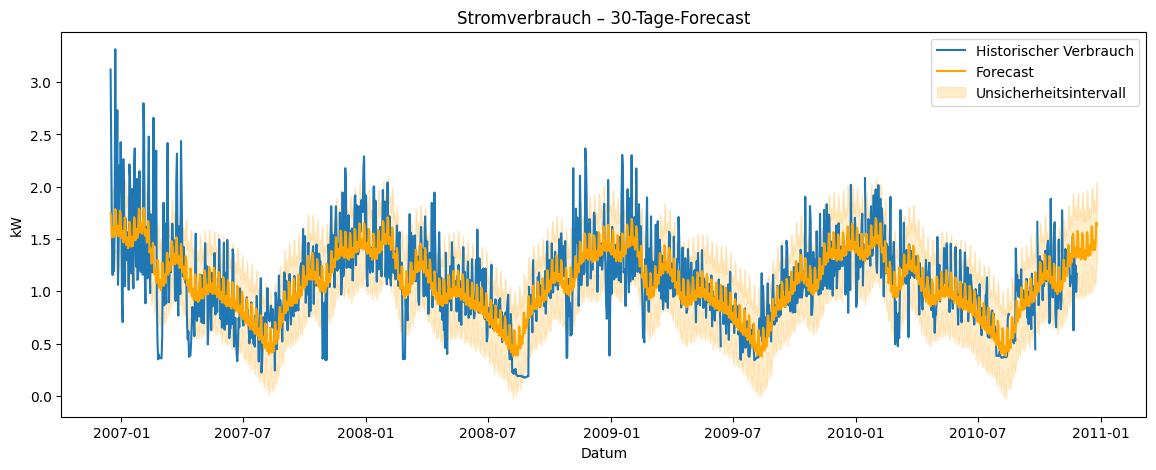

In [6]:
plt.figure(figsize=(14,5))
plt.plot(df_daily["ds"], df_daily["y"], label="Historischer Verbrauch")
plt.plot(forecast["ds"], forecast["yhat"], label="Forecast", color="orange")

plt.fill_between(
    forecast["ds"],
    forecast["yhat_lower"],
    forecast["yhat_upper"],
    color="orange",
    alpha=0.2,
    label="Unsicherheitsintervall"
)

plt.title("Stromverbrauch – 30-Tage-Forecast")
plt.xlabel("Datum")
plt.ylabel("kW")
plt.legend()
plt.show()


### 7. Prophet-Komponenten analysieren

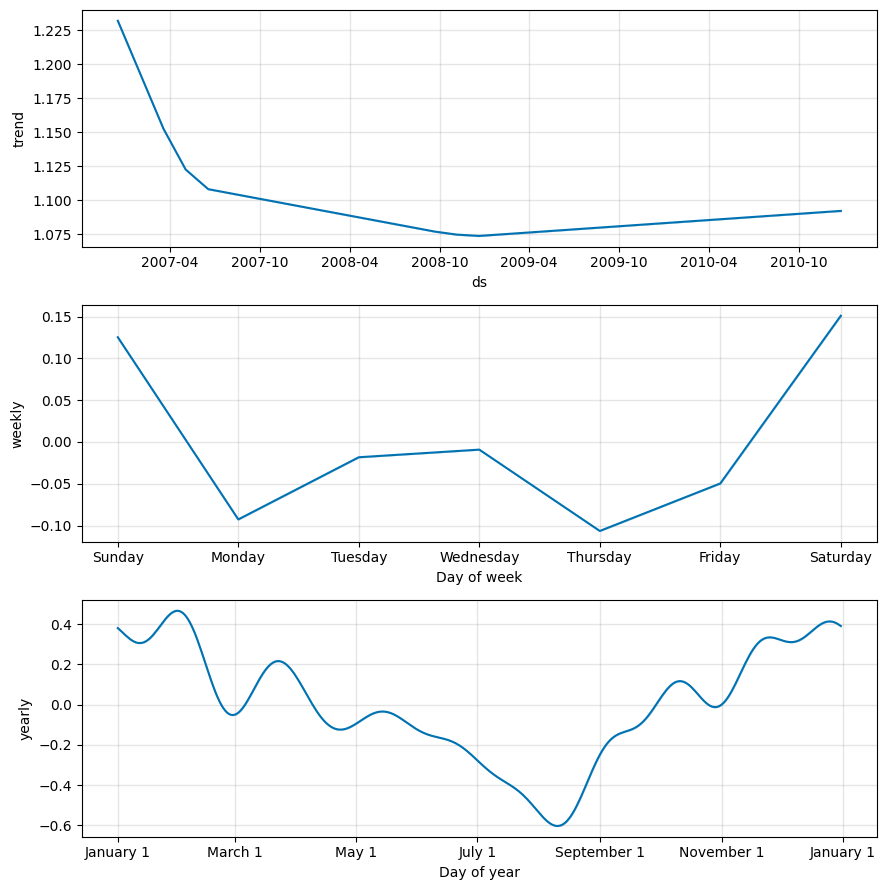

In [7]:
model.plot_components(forecast)
plt.show()


## Fazit – Forecasting

Das Prophet-Modell erkennt klare saisonale Muster im Stromverbrauch
und ermöglicht eine plausible Vorhersage für die kommenden 7 bis 30 Tage.

Der Forecast eignet sich besonders als:
- Unterstützung für Energieplanung
- Basis für Frühwarnsysteme
- Ergänzung zur Anomalieerkennung

In einem nächsten Schritt könnte der Forecast in Power BI oder Streamlit integriert werden,
um zukünftige Verbrauchsentwicklungen interaktiv darzustellen.


In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)

mae, rmse



(0.21503434798972507, 0.2966332824898574)

In [12]:
test = df_daily.iloc[-30:].copy()
test["y_naive"] = df_daily["y"].shift(1).iloc[-30:].values

mae_naive = mean_absolute_error(test["y"], test["y_naive"])
rmse_naive = np.sqrt(mean_squared_error(test["y"], test["y_naive"]))

print("Prophet MAE/RMSE:", mae, rmse)
print("Naive  MAE/RMSE:", mae_naive, rmse_naive)


Prophet MAE/RMSE: 0.21503434798972507 0.2966332824898574
Naive  MAE/RMSE: 0.24841980218855217 0.3571034702573499


MAE ≈ 0.22 kW

RMSE ≈ 0.30 kW

Im Mittel weicht die Prognose um etwa 0.22 kW vom tatsächlichen Tagesverbrauch ab.
Größere Abweichungen werden durch den RMSE stärker gewichtet.

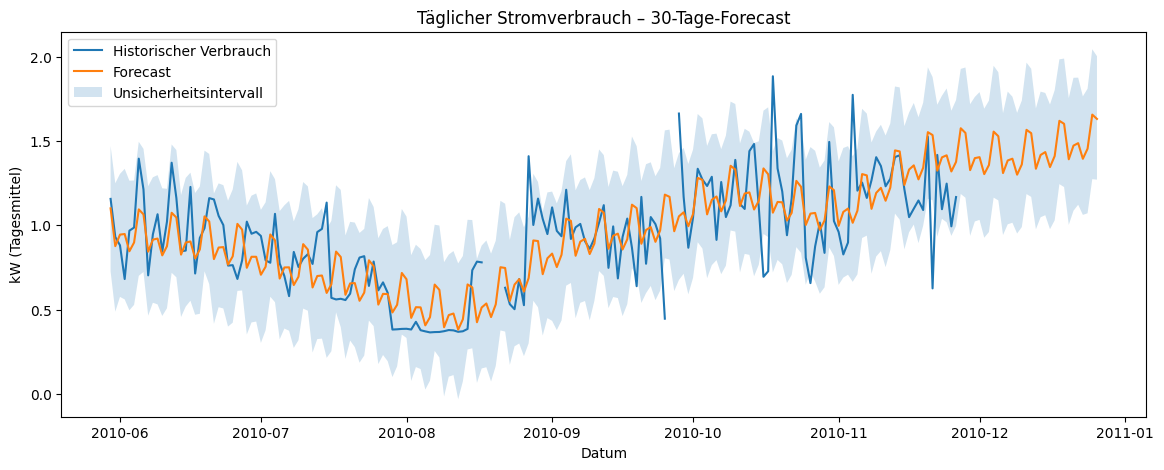

In [13]:
plt.figure(figsize=(14,5))

cutoff = df_daily["ds"].max() - pd.Timedelta(days=180)

plt.plot(
    df_daily[df_daily["ds"] >= cutoff]["ds"],
    df_daily[df_daily["ds"] >= cutoff]["y"],
    label="Historischer Verbrauch"
)

plt.plot(
    forecast[forecast["ds"] >= cutoff]["ds"],
    forecast[forecast["ds"] >= cutoff]["yhat"],
    label="Forecast"
)

plt.fill_between(
    forecast[forecast["ds"] >= cutoff]["ds"],
    forecast[forecast["ds"] >= cutoff]["yhat_lower"],
    forecast[forecast["ds"] >= cutoff]["yhat_upper"],
    alpha=0.2,
    label="Unsicherheitsintervall"
)

plt.title("Täglicher Stromverbrauch – 30-Tage-Forecast")
plt.xlabel("Datum")
plt.ylabel("kW (Tagesmittel)")
plt.legend()
plt.show()


## Fazit – Forecasting

Der tägliche Stromverbrauch weist klare saisonale Muster auf, die durch das Prophet-Modell
plausibel abgebildet werden. Insbesondere Wochen- und Jahresmuster sind deutlich erkennbar.

Der 30-Tage-Forecast eignet sich als erste Planungsgrundlage und ergänzt die Anomalieerkennung
um eine vorausschauende Perspektive.

Für dieses Projekt dient Prophet bewusst als Baseline-Modell und Demonstration eines
praxisnahen Forecasting-Ansatzes.

